
# Baseband delay-estimation experiments

This notebook implements and compares:

- Integer-sample matched-filter peak
- Gaussian peak interpolation
- Sinc interpolation around the correlation peak
- FFT zero-padding of the correlation peak
- Oversampling / resampling before correlation
- Oversampling + parabolic refinement

The main workflow is:

1. Generate a baseband PRN sequence.
2. Pulse-shape it so the signal is band-limited enough for interpolation to make sense.
3. Apply a **known fractional delay**.
4. Run matched filtering / autocorrelation.
5. Estimate the delay with several methods.
6. Compare estimation error over many random trials.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.signal import resample_poly
from IPython.display import display

In [2]:
import matplotlib.pyplot as plt

def apply_theme(bg="#FFFFFF", accent1="#275d38", accent2="#F2cd00"):
    plt.rcParams.update({
        # Figure + axes background
        "figure.facecolor": bg,
        "axes.facecolor": bg,

        # Text + labels
        "text.color": "white",
        "axes.labelcolor": "white",
        "axes.edgecolor": "white",
        "xtick.color": "white",
        "ytick.color": "white",

        # Grid
        "grid.color": "white",
        "grid.alpha": 0.15,

        # Lines default
        "axes.prop_cycle": plt.cycler(color=[accent1, accent2]),

        # Savefig consistency
        "savefig.facecolor": bg,
        "savefig.edgecolor": bg,
    })

apply_theme(
    bg="#0E1117",
    accent1="#4CC9F0",
    accent2="#F72585"
)


## Parameters

I am assuming that my carrier frequency is $457\,\mathrm{kHz}$, which in Canadian frequency regulations allows for a maximum bandwidth of $472 - 415 = 57\,\mathrm{kHz}$. This means that my chip rate, which directly affects my bandwidth, must be chosen such that my BPSK-modulated signal remains within a bandwidth of $57\,\mathrm{kHz}$.

$\therefore B_{max} = 57\,\mathrm{kHz}$. However, at Steven's request, I will redo these calculations at bandwidths of 4 kHz and 25 kHz.

A few notes:

- `Rc` is the chip rate, which was not selected from a closed-form bandwidth formula alone. Instead, it was tuned empirically by repeatedly generating the pulse-shaped waveform, measuring its occupied bandwidth, and adjusting $R_c$ until the waveform fit within the allowable spectral mask.
- `sps` is samples per chip in the digital simulation.
- Using a raised-cosine pulse shape makes the correlation peak smoother and more realistic for interpolation.
- To fall back to rectangular chips, use `USE_RAISED_COSINE = False`.
- With `alpha = 0.35`, the approximate occupied baseband bandwidth is $B \approx \frac{(1+\alpha)R_c}{2}$.

In [3]:
# -----------------------
# Simulation parameters
# -----------------------
Rc = 50e3            # chip rate [chips/s]
sps = 8               # samples per chip
Fs = Rc * sps         # sample rate [samples/s]

# These parameters ensure the chips are cosine-shaped, not rectangular
USE_RAISED_COSINE = True
alpha = 0.35          # raised-cosine rolloff
span = 8              # pulse-shape span in chips

snr_db = 20           # AWGN SNR used in Monte Carlo section
rng = np.random.default_rng(0)

print(f"Rc = {Rc/1e6:.3f} MHz")
print(f"Fs = {Fs/1e6:.3f} MHz")
print(f"Samples/chip = {sps}")
print(f"Sample period = {1/Fs*1e9:.3f} ns")

Rc = 0.050 MHz
Fs = 0.400 MHz
Samples/chip = 8
Sample period = 2500.000 ns


## PRN generator

In [4]:
def generate_ca_code(prn=1):
    """
    Generate GPS C/A Gold code chips for PRN 1..32.
    Returns chips mapped to {-1, +1}.
    """
    g2_taps = {
        1: (2, 6),  2: (3, 7),  3: (4, 8),  4: (5, 9),
        5: (1, 9),  6: (2,10),  7: (1, 8),  8: (2, 9),
        9: (3,10), 10: (2, 3), 11: (3, 4), 12: (5, 6),
        13:(6, 7), 14:(7, 8), 15:(8, 9), 16:(9,10),
        17:(1, 4), 18:(2, 5), 19:(3, 6), 20:(4, 7),
        21:(5, 8), 22:(6, 9), 23:(1, 3), 24:(4, 6),
        25:(5, 7), 26:(6, 8), 27:(7, 9), 28:(8,10),
        29:(1, 6), 30:(2, 7), 31:(3, 8), 32:(4, 9),
    }
    tap1, tap2 = g2_taps[prn]

    g1 = np.ones(10, dtype=int)
    g2 = np.ones(10, dtype=int)
    code = np.zeros(1023, dtype=int)

    for i in range(1023):
        g1_out = g1[-1]
        g2_out = g2[-tap1] ^ g2[-tap2]
        code[i] = g1_out ^ g2_out

        g1_feedback = g1[2] ^ g1[9]
        g2_feedback = g2[1] ^ g2[2] ^ g2[5] ^ g2[7] ^ g2[8] ^ g2[9]

        g1[1:] = g1[:-1]
        g1[0] = g1_feedback

        g2[1:] = g2[:-1]
        g2[0] = g2_feedback

    # Convert from [0,1] to [-1,1]
    return 2 * code - 1

## Baseband signal construction

A few notes:
- The `raised_cosine()` function is used to shape the MLS of chips as sinusoidal instead of rectangular. Instead of transmitting abrupt rectangular chips, the chip sequence is pulse-shaped with a raised-cosine filter so that the waveform becomes band-limited and occupies less spectral bandwidth. This smooths the time-domain transitions between chips, reduces high-frequency sidelobes, and produces a more realistic communication signal for delay-estimation experiments.
- Can learn more about raised cosine filters [here](https://www.youtube.com/watch?v=Qe8NQx4ibE8).
- Smooth pulses spread less than rectangular pulses, helping them avoid interfering with their neighbors.
- Square pulses create infinite bandwidth, with the high frequencies in the band becoming cut off in real systems. This distorts the pulse into a smeared sinc pulse.
- Using square root raised cosine pulses, at each sample, all other pulses are exactly zero.

In [5]:
def raised_cosine(beta, sps, span):
    """
    Unit-energy raised-cosine pulse.
    Time axis is in chip periods.
    """
    t = np.arange(-span * sps / 2, span * sps / 2 + 1) / sps
    h = np.zeros_like(t, dtype=float)

    for i, ti in enumerate(t):
        if np.isclose(ti, 0.0):
            h[i] = 1.0
        elif beta != 0 and np.isclose(abs(2 * beta * ti), 1.0):
            # L'Hopital special-case point
            h[i] = (np.pi / 4) * np.sinc(1 / (2 * beta))
        else:
            h[i] = np.sinc(ti) * np.cos(np.pi * beta * ti) / (1 - (2 * beta * ti) ** 2)

    h /= np.sqrt(np.sum(h**2))
    return h


def make_baseband_signal(prn=1, sps=8, use_raised_cosine=True, alpha=0.35, span=8):
    # Create the sequence of 1023 numbers from [-1,1]
    chips = generate_ca_code(prn)

    if use_raised_cosine:
        up = np.zeros(len(chips) * sps)
        up[::sps] = chips
        h = raised_cosine(alpha, sps, span)
        x = np.convolve(up, h, mode="same")
    else:
        x = np.repeat(chips, sps).astype(float)

    x = x / np.linalg.norm(x)
    return x, chips


def measure_power_bandwidth(x, Fs, power_fraction=0.99, pad_factor=8):
    """
    Measure occupied bandwidth containing `power_fraction` of total power.
    
    Returns:
        bw       : occupied bandwidth in Hz
        f_low    : lower frequency bound in Hz
        f_high   : upper frequency bound in Hz
        f        : frequency axis in Hz
        P        : normalized power spectrum
    """
    N = len(x)
    Nfft = pad_factor * N

    # FFT and centered spectrum
    X = np.fft.fftshift(np.fft.fft(x, n=Nfft))
    f = np.fft.fftshift(np.fft.fftfreq(Nfft, d=1/Fs))

    # Power spectrum
    P = np.abs(X)**2

    # Normalize total power to 1
    P = P / np.sum(P)

    # Cumulative power
    C = np.cumsum(P)

    # Find symmetric central interval containing desired power
    lower_target = (1 - power_fraction) / 2
    upper_target = 1 - lower_target

    i_low = np.searchsorted(C, lower_target)
    i_high = np.searchsorted(C, upper_target)

    f_low = f[i_low]
    f_high = f[i_high]
    bw = f_high - f_low

    return bw, f_low, f_high, f, P


def tile_periodic_signal(x_period, repeats=5):
    """
    Explicitly tile one waveform period to model continuous periodic transmission.
    """
    return np.tile(np.asarray(x_period, dtype=float), repeats)


def crop_center_period(x_tiled, period_len):
    """
    Extract the center period from an odd-number tiled waveform.
    """
    total_len = len(x_tiled)
    center_start = total_len // 2 - period_len // 2
    return np.asarray(x_tiled[center_start:center_start + period_len], dtype=float)


x_ref, chips = make_baseband_signal(
    prn=1,
    sps=sps,
    use_raised_cosine=USE_RAISED_COSINE,
    alpha=alpha,
    span=span
)


t = np.arange(len(x_ref)) / Fs

print("Signal length (samples):", len(x_ref))
print("Signal duration (ms):", len(x_ref) / Fs * 1e3)

Signal length (samples): 8184
Signal duration (ms): 20.459999999999997


99% power bandwidth: 52.468 kHz
Lower edge: -26.234 kHz
Upper edge: 26.234 kHz


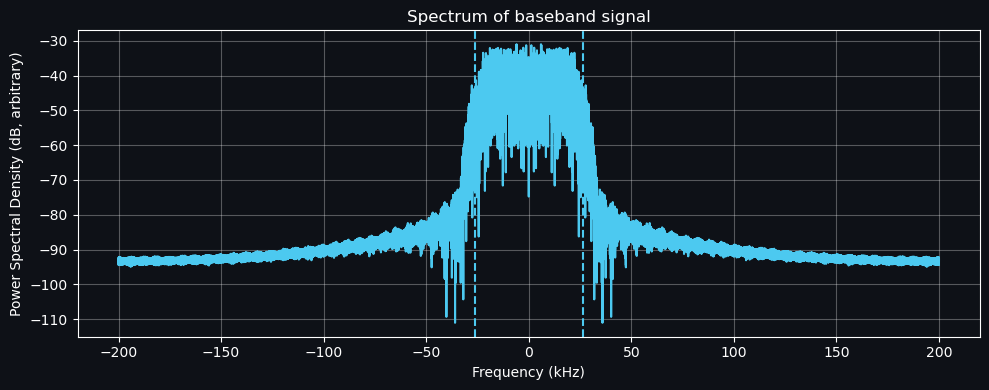

In [6]:
bw, f_low, f_high, f, P = measure_power_bandwidth(x_ref, Fs, power_fraction=0.99)

print(f"99% power bandwidth: {bw/1e3:.3f} kHz")
print(f"Lower edge: {f_low/1e3:.3f} kHz")
print(f"Upper edge: {f_high/1e3:.3f} kHz")

plt.figure(figsize=(10, 4))
plt.plot(f/1e3, 10*np.log10(P + 1e-20))
plt.axvline(f_low/1e3, linestyle='--')
plt.axvline(f_high/1e3, linestyle='--')
plt.xlabel("Frequency (kHz)")
plt.ylabel("Power Spectral Density (dB, arbitrary)")
plt.title("Spectrum of baseband signal")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Display the baseband signal, normalized by energy

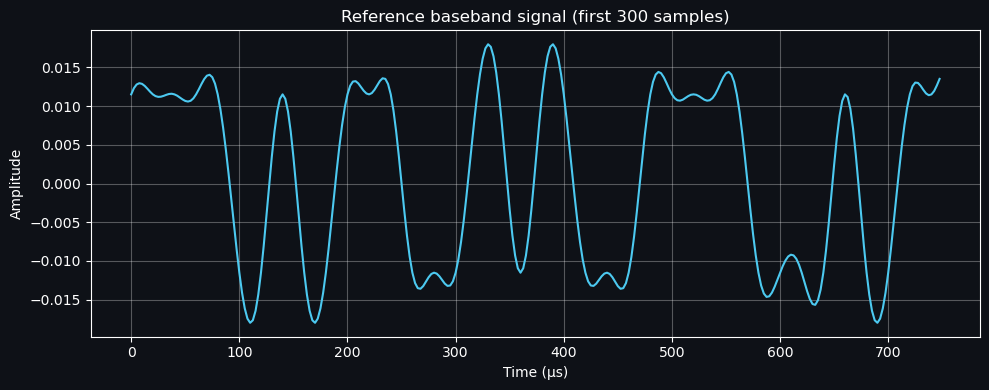

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(t[:300] * 1e6, x_ref[:300])
plt.xlabel("Time (µs)")
plt.ylabel("Amplitude")
plt.title("Reference baseband signal (first 300 samples)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Fractional delay model

This uses a **frequency-domain delay** so the injected delay can be a non-integer number of samples.


In [8]:
def fractional_delay(x, delay_samples):
    """
    Apply a fractional delay using the Fourier shift theorem.
    Positive delay shifts the signal to the right.
    """
    N = len(x)
    X = np.fft.fft(x)
    k = np.fft.fftfreq(N)
    y = np.fft.ifft(X * np.exp(-1j * 2 * np.pi * k * delay_samples))
    return np.real_if_close(y)


def add_awgn(x, snr_db, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    sig_power = np.mean(np.abs(x) ** 2)
    noise_power = sig_power / (10 ** (snr_db / 10))
    noise = rng.normal(0, np.sqrt(noise_power), size=len(x))
    return x + noise

## Matched filter / correlation

In [9]:

def matched_filter_correlation(x_ref, x_rx):
    corr = signal.correlate(x_rx, x_ref, mode="full", method="fft")
    lags = signal.correlation_lags(len(x_rx), len(x_ref), mode="full")
    return corr, lags


def integer_peak_delay(corr, lags):
    idx = np.argmax(np.abs(corr))
    return lags[idx], idx


## Peak interpolation methods

In [10]:

def gaussian_peak_offset(corr, idx):
    """
    3-point Gaussian interpolation on |corr|.
    Returns the fractional offset relative to idx.
    """
    if idx <= 0 or idx >= len(corr) - 1:
        return 0.0

    y = np.abs(corr[idx-1:idx+2]) + 1e-15
    y1, y2, y3 = np.log(y)

    denom = y1 - 2*y2 + y3
    if np.isclose(denom, 0.0):
        return 0.0

    return 0.5 * (y1 - y3) / denom


def sinc_interpolated_peak_offset(corr, idx, half_window=12, fine_points=801):
    """
    Local truncated sinc interpolation around the correlation peak.
    This is a finite-window approximation to ideal band-limited interpolation.
    """
    start = max(0, idx - half_window)
    stop = min(len(corr), idx + half_window + 1)

    n = np.arange(start, stop, dtype=float)
    y = np.real(corr[start:stop])

    x_fine = np.linspace(idx - 1.0, idx + 1.0, fine_points)
    y_fine = np.sum(y[:, None] * np.sinc(x_fine[None, :] - n[:, None]), axis=0)

    fine_idx = np.argmax(np.abs(y_fine))
    return x_fine[fine_idx] - idx


def fft_zero_pad_peak_offset(corr, idx, half_window=16, up_factor=64):
    """
    Fourier interpolation of a local correlation window using resample(),
    which is equivalent to FFT-domain zero padding for periodic interpolation.
    """
    start = max(0, idx - half_window)
    stop = min(len(corr), idx + half_window + 1)

    y = np.real(corr[start:stop])
    y_up = signal.resample(y, len(y) * up_factor)

    x_up = np.linspace(start, stop - 1, len(y_up))
    fine_idx = np.argmax(np.abs(y_up))
    return x_up[fine_idx] - idx


def oversample_then_correlate_delay(x_ref, x_rx, up_factor=8):
    """
    Upsample both signals digitally, correlate, then take the integer peak.
    """
    x_ref_up = resample_poly(x_ref, up_factor, 1)
    x_rx_up = resample_poly(x_rx, up_factor, 1)

    corr_up = signal.correlate(x_rx_up, x_ref_up, mode="full", method="fft")
    lags_up = signal.correlation_lags(len(x_rx_up), len(x_ref_up), mode="full")

    idx_up = np.argmax(np.abs(corr_up))
    return lags_up[idx_up] / up_factor


def oversample_then_correlate_gaussian_delay(x_ref, x_rx, up_factor=8):
    """
    Upsample first, then correlate, then apply Gaussian peak refinement.
    """
    x_ref_up = resample_poly(x_ref, up_factor, 1)
    x_rx_up = resample_poly(x_rx, up_factor, 1)

    corr_up = signal.correlate(x_rx_up, x_ref_up, mode="full", method="fft")
    lags_up = signal.correlation_lags(len(x_rx_up), len(x_ref_up), mode="full")

    idx_up = np.argmax(np.abs(corr_up))
    frac_up = gaussian_peak_offset(corr_up, idx_up)
    return (lags_up[idx_up] + frac_up) / up_factor


def estimate_delay(x_ref, x_rx, method):
    corr, lags = matched_filter_correlation(x_ref, x_rx)
    lag_int, idx = integer_peak_delay(corr, lags)

    if method == "integer":
        return float(lag_int), corr, lags

    if method == "gaussian":
        frac = gaussian_peak_offset(corr, idx)
        return float(np.real(lag_int + frac)), corr, lags

    if method == "sinc":
        frac = sinc_interpolated_peak_offset(corr, idx)
        return float(np.real(lag_int + frac)), corr, lags

    if method == "fft_zero_pad":
        frac = fft_zero_pad_peak_offset(corr, idx)
        return float(np.real(lag_int + frac)), corr, lags

    if method == "oversample_x8":
        return float(oversample_then_correlate_delay(x_ref, x_rx, up_factor=8)), corr, lags

    if method == "oversample_x8_gaussian":
        return float(oversample_then_correlate_gaussian_delay(x_ref, x_rx, up_factor=8)), corr, lags

    raise ValueError(f"Unknown method: {method}")


## Single-trial example

In [11]:

true_delay = 12.37  # samples
x_rx = fractional_delay(x_ref, true_delay)
x_rx = add_awgn(x_rx, snr_db=snr_db, rng=rng)

methods = [
    "integer",
    "gaussian",
    "sinc",
    "fft_zero_pad",
    "oversample_x8",
    "oversample_x8_gaussian",
]

rows = []
for method in methods:
    est, corr, lags = estimate_delay(x_ref, x_rx, method)
    rows.append({
        "method": method,
        "true_delay_samples": true_delay,
        "estimated_delay_samples": est,
        "error_samples": est - true_delay,
        "error_ns": (est - true_delay) / Fs * 1e9
    })

single_trial_df = pd.DataFrame(rows)
display(single_trial_df)


,method,true_delay_samples,estimated_delay_samples,error_samples,error_ns
0,integer,12.37,12.000000,-0.370000,-925.000000
1,gaussian,12.37,12.373117,0.003117,7.792976
2,sinc,12.37,12.385000,0.015000,37.500000
3,fft_zero_pad,12.37,11.901468,-0.468532,-1171.328754
4,oversample_x8,12.37,12.375000,0.005000,12.500000
5,oversample_x8_gaussian,12.37,12.371154,0.001154,2.885851


3 dB width: 7 samples


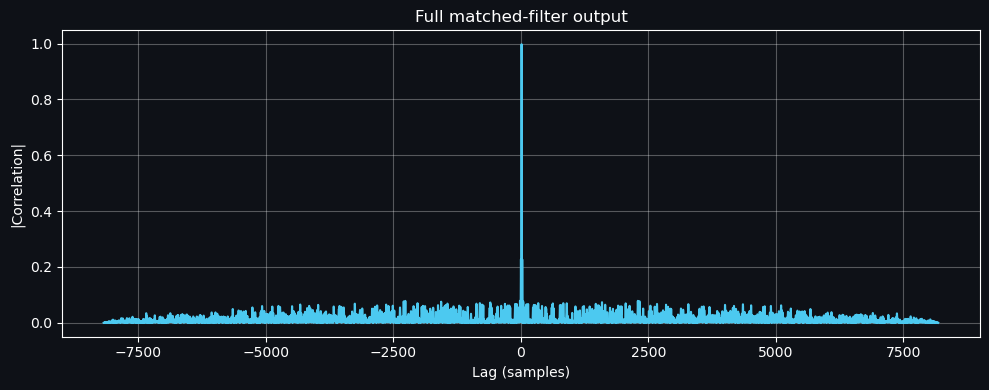

16367


In [12]:
corr, lags = matched_filter_correlation(x_ref, x_rx)
peak_idx = np.argmax(np.abs(corr))

peak_val = np.abs(corr[peak_idx])
half_power = peak_val / np.sqrt(2)
above = np.where(np.abs(corr) >= half_power)[0]
width_3db_samples = lags[above[-1]] - lags[above[0]]
print(f"3 dB width: {width_3db_samples} samples")

plt.figure(figsize=(10, 4))
# plt.plot(lags[8100:8300], np.abs(corr)[8100:8300])
plt.plot(lags, np.abs(corr))
plt.xlabel("Lag (samples)")
plt.ylabel("|Correlation|")
plt.title("Full matched-filter output")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(len(lags))

## Monte Carlo comparison

In [13]:

def run_monte_carlo(x_ref, methods, trials=200, snr_db=20, delay_range=(0.0, 20.0), rng=None):
    if rng is None:
        rng = np.random.default_rng()

    results = []

    for method in methods:
        errors = []

        for _ in range(trials):
            true_delay = rng.uniform(*delay_range)
            x_rx = fractional_delay(x_ref, true_delay)
            x_rx = add_awgn(x_rx, snr_db=snr_db, rng=rng)

            est, _, _ = estimate_delay(x_ref, x_rx, method)
            errors.append(est - true_delay)

        errors = np.array(errors)

        results.append({
            "method": method,
            "MAE_samples": np.mean(np.abs(errors)),
            "RMSE_samples": np.sqrt(np.mean(errors**2)),
            "max_abs_error_samples": np.max(np.abs(errors)),
            "MAE_ns": np.mean(np.abs(errors)) / Fs * 1e9,
            "RMSE_ns": np.sqrt(np.mean(errors**2)) / Fs * 1e9,
        })

    return pd.DataFrame(results).sort_values("RMSE_samples")


mc_df = run_monte_carlo(
    x_ref,
    methods=methods,
    trials=200,
    snr_db=snr_db,
    delay_range=(0.0, 20.0),
    rng=np.random.default_rng(1)
)

display(mc_df)


,method,MAE_samples,RMSE_samples,max_abs_error_samples,MAE_ns,RMSE_ns
1,gaussian,0.004468,0.005536,0.014205,11.169124,13.839949
5,oversample_x8_gaussian,0.004567,0.005612,0.015470,11.417318,14.030588
2,sinc,0.011134,0.012596,0.026205,27.835788,31.489933
4,oversample_x8,0.033846,0.038593,0.074091,84.614458,96.481334
0,integer,0.255605,0.293155,0.496098,639.012237,732.888520
3,fft_zero_pad,0.478907,0.479011,0.498134,1197.268239,1197.527655


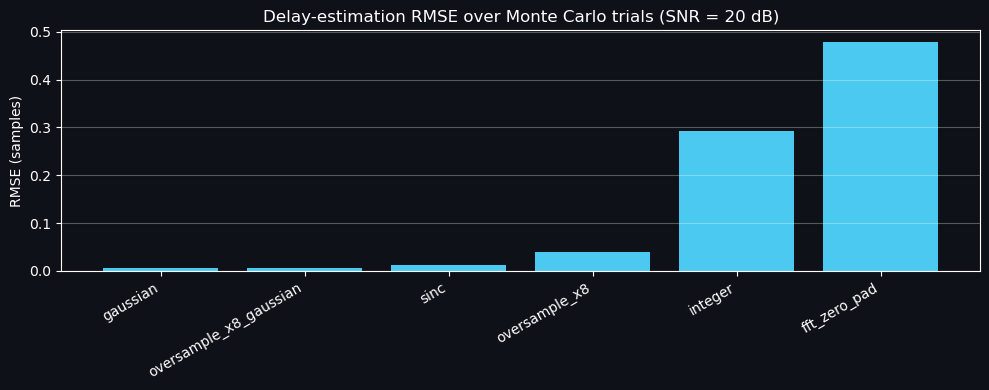

In [14]:

plt.figure(figsize=(10, 4))
plt.bar(mc_df["method"], mc_df["RMSE_samples"])
plt.ylabel("RMSE (samples)")
plt.title(f"Delay-estimation RMSE over Monte Carlo trials (SNR = {snr_db} dB)")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



## What to look for

Typical behavior you may see:

- **Integer peak** is limited to whole-sample resolution.
- **Gaussian interpolation** often gives a big improvement with very little complexity.
- **Sinc interpolation** can help, but with a truncated local window it may be sensitive to shape mismatch.
- **FFT zero-padding** is a practical way to densify the correlation peak.
- **Oversampling after acquisition** does **not** create new information by itself, but it can make peak picking and interpolation easier numerically.
- **Oversampling + interpolation** is often better than oversampling alone.

## Next things to try

1. Increase or decrease `sps` to see how much raw sample rate matters.
2. Compare rectangular chips vs raised-cosine pulse shaping.
3. Sweep `snr_db`, distance resolution to bandwidth/chiprate, distance resolution to samples/oversampling
4. Add a true propagation delay in **seconds** and convert the error from samples to distance.
5. Repeat with shorter PRN lengths if you want to see how peak width changes with code length.
